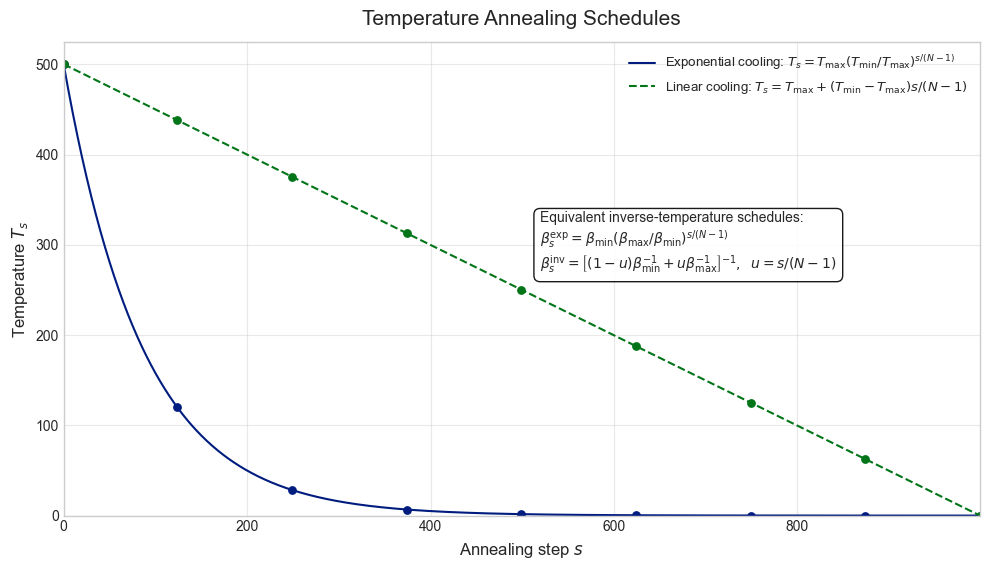

In [9]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-dark-palette")

# Annealing parameters
T_max = 500.0
T_min = 0.005
n_steps = 1000

s = np.arange(n_steps)
u = s / (n_steps - 1)

# Temperature schedules
T_exponential = T_max * (T_min / T_max) ** u
T_linear = T_max + (T_min - T_max) * u

# Equivalent inverse-temperature schedules, beta = 1 / T
beta_min = 1.0 / T_max
beta_max = 1.0 / T_min

beta_exponential = beta_min * (beta_max / beta_min) ** u
beta_inverse_proportional = 1.0 / (
    (1.0 - u) / beta_min + u / beta_max
)

# Plot temperature
fig, ax = plt.subplots(figsize=(10, 5.8))

ax.plot(
    s, T_exponential,
    linewidth=1.5,
    label=r"Exponential cooling: $T_s=T_{\max}(T_{\min}/T_{\max})^{s/(N-1)}$"
)

ax.plot(
    s, T_linear,
    linewidth=1.5,
    linestyle="--",
    label=r"Linear cooling: $T_s=T_{\max}+(T_{\min}-T_{\max})s/(N-1)$"
)

# Sparse markers for readability
marker_steps = np.linspace(0, n_steps - 1, 9, dtype=int)
ax.scatter(marker_steps, T_exponential[marker_steps], s=28)
ax.scatter(marker_steps, T_linear[marker_steps], s=28)

ax.set_title("Temperature Annealing Schedules", fontsize=15, pad=12)
ax.set_xlabel(r"Annealing step $s$", fontsize=12)
ax.set_ylabel(r"Temperature $T_s$", fontsize=12)
ax.set_xlim(0, n_steps - 1)
ax.set_ylim(bottom=0)
ax.grid(True, which="major", alpha=0.45)
ax.legend(fontsize=9.5, loc="upper right")

beta_text = (
    r"Equivalent inverse-temperature schedules:" "\n"
    r"$\beta_s^{\rm exp}"
    r"=\beta_{\min}(\beta_{\max}/\beta_{\min})^{s/(N-1)}$" "\n"
    r"$\beta_s^{\rm inv}"
    r"=\left[(1-u)\beta_{\min}^{-1}+u\beta_{\max}^{-1}\right]^{-1},$"
    r"  $u=s/(N-1)$"
)

ax.text(
    0.52, 0.52, beta_text,
    transform=ax.transAxes,
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.45", facecolor="white", alpha=0.9)
)

plt.tight_layout()
plt.show()

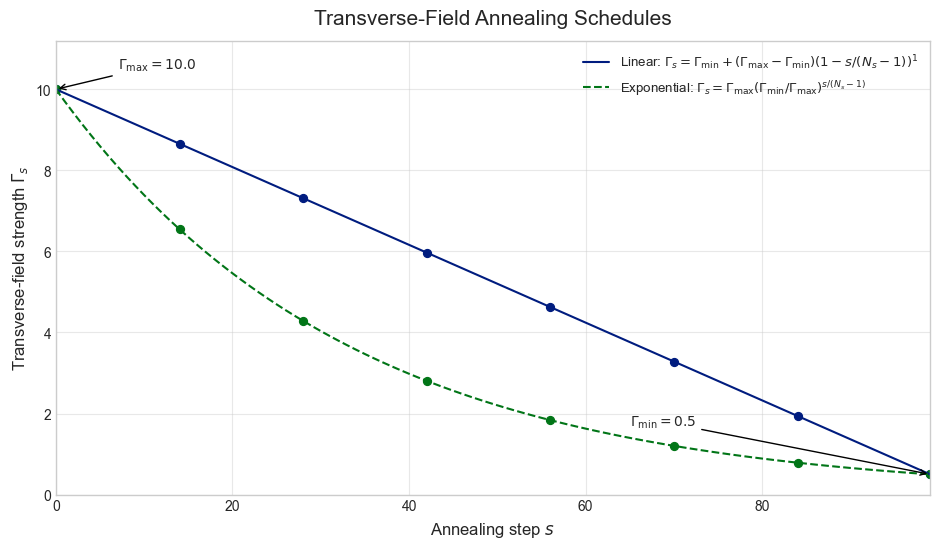

In [10]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-dark-palette")

# Transverse-field parameters
gamma_max = 10.0
gamma_min = 0.5
n_steps = 100
power = 1

s = np.arange(n_steps)
u = s / (n_steps - 1)

# Proposed schedules
gamma_linear = (
    gamma_min
    + (gamma_max - gamma_min) * (1.0 - u) ** power
)

gamma_exponential = (
    gamma_max * (gamma_min / gamma_max) ** u
)

fig, ax = plt.subplots(figsize=(9.5, 5.6))

ax.plot(
    s, gamma_linear,
    linewidth=1.5,
    label=(
        rf"Linear: "
        rf"$\Gamma_s=\Gamma_{{\min}}+"
        rf"(\Gamma_{{\max}}-\Gamma_{{\min}})"
        rf"(1-s/(N_s-1))^{{{power}}}$"
    )
)

ax.plot(
    s, gamma_exponential,
    linewidth=1.5,
    linestyle="--",
    label=(
        r"Exponential: "
        r"$\Gamma_s=\Gamma_{\max}"
        r"(\Gamma_{\min}/\Gamma_{\max})^{s/(N_s-1)}$"
    )
)

# Mark selected steps
marker_steps = np.linspace(0, n_steps - 1, 8, dtype=int)
ax.scatter(marker_steps, gamma_linear[marker_steps], s=32)
ax.scatter(marker_steps, gamma_exponential[marker_steps], s=32)

# Endpoint annotations
ax.annotate(
    rf"$\Gamma_{{\max}}={gamma_max}$",
    xy=(0, gamma_max),
    xytext=(7, gamma_max + 0.5),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

ax.annotate(
    rf"$\Gamma_{{\min}}={gamma_min}$",
    xy=(n_steps - 1, gamma_min),
    xytext=(n_steps - 35, gamma_min + 1.2),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

ax.set_title("Transverse-Field Annealing Schedules", fontsize=15, pad=12)
ax.set_xlabel(r"Annealing step $s$", fontsize=12)
ax.set_ylabel(r"Transverse-field strength $\Gamma_s$", fontsize=12)
ax.set_xlim(0, n_steps - 1)
ax.set_ylim(0, gamma_max * 1.12)
ax.grid(True, which="major", alpha=0.45)
ax.legend(fontsize=9.5, loc="upper right")

plt.tight_layout()
plt.show()

In [11]:
from pathlib import Path
import pandas as pd
import numpy as np

V1_DIR = Path.home() / "Desktop/QeFEM/main/maxcut_results/v1/qefem_v1_outputs"

# Inspect available CSV files
csv_files = sorted(V1_DIR.glob("*.csv"))
print("CSV files found:")
for path in csv_files:
    print(" ", path.name)

# Set this to the consolidated G1--G54 result file
RESULTS_FILE = V1_DIR / "qefem_anneal_G1_G54_final_results.csv"

df = pd.read_csv(RESULTS_FILE)
print("\nColumns:", df.columns.tolist())
display(df.head())

CSV files found:
  G10_qefem_anneal_history.csv
  G10_qefem_anneal_summary.csv
  G11_qefem_anneal_history.csv
  G11_qefem_anneal_summary.csv
  G12_qefem_anneal_history.csv
  G12_qefem_anneal_summary.csv
  G13_qefem_anneal_history.csv
  G13_qefem_anneal_summary.csv
  G14_qefem_anneal_history.csv
  G14_qefem_anneal_summary.csv
  G15_qefem_anneal_history.csv
  G15_qefem_anneal_summary.csv
  G16_qefem_anneal_history.csv
  G16_qefem_anneal_summary.csv
  G17_qefem_anneal_history.csv
  G17_qefem_anneal_summary.csv
  G18_qefem_anneal_history.csv
  G18_qefem_anneal_summary.csv
  G19_qefem_anneal_history.csv
  G19_qefem_anneal_summary.csv
  G1_qefem_anneal_history.csv
  G1_qefem_anneal_summary.csv
  G1_qefem_gamma0_history.csv
  G1_qefem_gamma0_summary.csv
  G20_qefem_anneal_history.csv
  G20_qefem_anneal_summary.csv
  G21_qefem_anneal_history.csv
  G21_qefem_anneal_summary.csv
  G22_qefem_anneal_history.csv
  G22_qefem_anneal_summary.csv
  G23_qefem_anneal_history.csv
  G23_qefem_anneal_summary

,instance,nodes,edges,mode,gamma_mode,gamma_max,gamma_min,n_steps,replicas,seed,...,vanilla_cut,vanilla_gap,vanilla_percent_accuracy,vanilla_runtime_sec,delta_cut_vs_vanilla,delta_gap_vs_vanilla,delta_accuracy_vs_vanilla,runtime_ratio_vs_vanilla,history_path,summary_path
0,G1,800,19176,qefem_anneal,anneal,1.0,0.0,1000,128,0,...,11446.0,178.0,98.468685,4.368305,165.0,165.0,1.419477,4.494935,qefem_v1_outputs/G1_qefem_anneal_history.csv,qefem_v1_outputs/G1_qefem_anneal_summary.csv
1,G2,800,19176,qefem_anneal,anneal,1.0,0.0,1000,128,0,...,11435.0,185.0,98.407917,4.299664,175.0,175.0,1.506024,4.580450,qefem_v1_outputs/G2_qefem_anneal_history.csv,qefem_v1_outputs/G2_qefem_anneal_summary.csv
2,G3,800,19176,qefem_anneal,anneal,1.0,0.0,1000,128,0,...,11443.0,179.0,98.459818,4.356321,167.0,167.0,1.436930,4.517880,qefem_v1_outputs/G3_qefem_anneal_history.csv,qefem_v1_outputs/G3_qefem_anneal_summary.csv
3,G4,800,19176,qefem_anneal,anneal,1.0,0.0,1000,128,0,...,11503.0,143.0,98.772111,4.275009,134.0,134.0,1.150610,4.575945,qefem_v1_outputs/G4_qefem_anneal_history.csv,qefem_v1_outputs/G4_qefem_anneal_summary.csv
4,G5,800,19176,qefem_anneal,anneal,1.0,0.0,1000,128,0,...,11450.0,181.0,98.443814,4.161925,172.0,172.0,1.478807,4.796209,qefem_v1_outputs/G5_qefem_anneal_history.csv,qefem_v1_outputs/G5_qefem_anneal_summary.csv


In [12]:
plot_df = df[["instance", "best_cut", "best_value", "gap", "percent_accuracy"]].copy()

plot_df["graph_id"] = (
    plot_df["instance"]
    .astype(str)
    .str.extract(r"(\d+)", expand=False)
    .astype(int)
)

plot_df = (
    plot_df.query("1 <= graph_id <= 54")
    .sort_values("graph_id")
    .reset_index(drop=True)
)

# Percentage gap relative to the best-known cut
plot_df["gap_percent"] = (
    100.0
    * plot_df["gap"]
    / plot_df["best_value"].abs()
)

# Remove tiny floating-point noise
plot_df.loc[
    np.isclose(plot_df["gap_percent"], 0.0, atol=1e-10),
    "gap_percent"
] = 0.0

display(plot_df.head())
print(f"Loaded {len(plot_df)} GSet instances.")

,instance,best_cut,best_value,gap,percent_accuracy,graph_id,gap_percent
0,G1,11611.0,11624,13.0,99.888162,1,0.111838
1,G2,11610.0,11620,10.0,99.913941,2,0.086059
2,G3,11610.0,11622,12.0,99.896748,3,0.103252
3,G4,11637.0,11646,9.0,99.922720,4,0.077280
4,G5,11622.0,11631,9.0,99.922621,5,0.077379


Loaded 54 GSet instances.


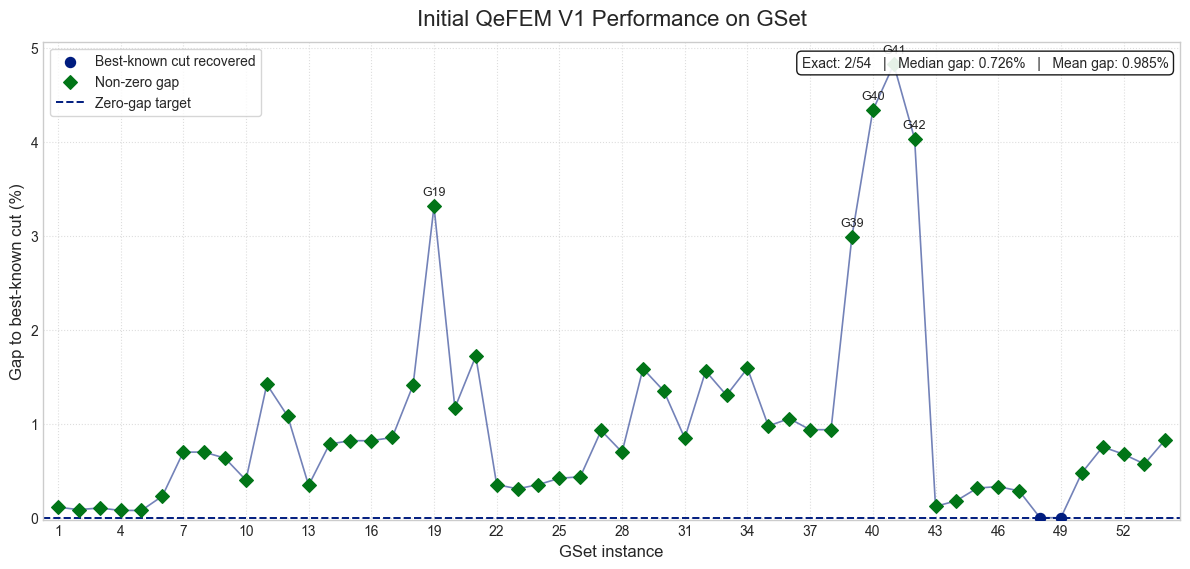

Saved: /Users/ronit/Desktop/QeFEM/main/maxcut_results/v1/qefem_v1_outputs/presentation_plots/qefem_v1_gap_vs_gset.pdf


In [13]:
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use("seaborn-v0_8-whitegrid")

PLOT_DIR = V1_DIR / "presentation_plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

exact = plot_df["gap_percent"] == 0
non_exact = ~exact

fig, ax = plt.subplots(figsize=(12, 5.8))

# Connecting line to reveal instance-dependent structure
ax.plot(
    plot_df["graph_id"],
    plot_df["gap_percent"],
    linewidth=1.2,
    alpha=0.55,
    zorder=1
)

# Exact and non-exact instances shown separately
ax.scatter(
    plot_df.loc[exact, "graph_id"],
    plot_df.loc[exact, "gap_percent"],
    marker="o",
    s=52,
    label="Best-known cut recovered",
    zorder=3
)

ax.scatter(
    plot_df.loc[non_exact, "graph_id"],
    plot_df.loc[non_exact, "gap_percent"],
    marker="D",
    s=48,
    label="Non-zero gap",
    zorder=3
)

ax.axhline(
    0.0,
    linewidth=1.4,
    linestyle="--",
    label="Zero-gap target"
)

# Label only the five largest gaps
largest = plot_df.nlargest(5, "gap_percent")
for _, row in largest.iterrows():
    ax.annotate(
        f"G{int(row['graph_id'])}",
        xy=(row["graph_id"], row["gap_percent"]),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=9
    )

ax.set_title(
    "Initial QeFEM V1 Performance on GSet",
    fontsize=16,
    pad=12
)
ax.set_xlabel("GSet instance", fontsize=12)
ax.set_ylabel("Gap to best-known cut (%)", fontsize=12)

ax.set_xticks(np.arange(1, 55, 3))
ax.set_xlim(0.3, 54.7)
ax.set_ylim(bottom=-0.02)

ax.grid(True, which="major", linestyle=":", alpha=0.65)
ax.legend(frameon=True, fontsize=10, loc="upper left")

summary = (
    f"Exact: {exact.sum()}/54   |   "
    f"Median gap: {plot_df['gap_percent'].median():.3f}%   |   "
    f"Mean gap: {plot_df['gap_percent'].mean():.3f}%"
)

ax.text(
    0.99, 0.97,
    summary,
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.35", facecolor="white", alpha=0.9)
)

fig.tight_layout()

output_path = PLOT_DIR / "qefem_v1_gap_vs_gset.pdf"
fig.savefig(output_path, bbox_inches="tight")
fig.savefig(output_path.with_suffix(".png"), dpi=300, bbox_inches="tight")

plt.show()
print("Saved:", output_path)

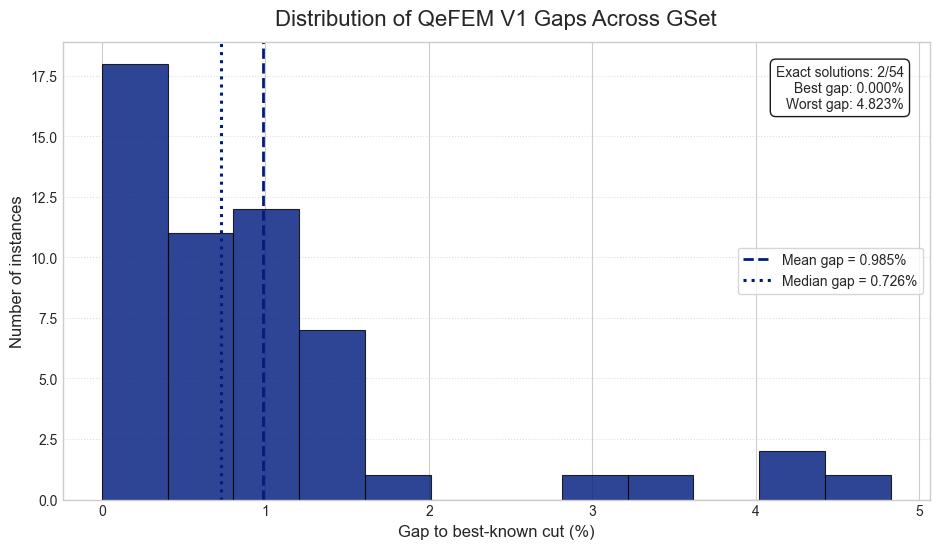

Saved: /Users/ronit/Desktop/QeFEM/main/maxcut_results/v1/qefem_v1_outputs/presentation_plots/qefem_v1_gap_histogram.pdf


In [14]:
plt.style.use("seaborn-v0_8-whitegrid")

gaps = plot_df["gap_percent"].to_numpy()

# Freedman-Diaconis bin width, with a sensible fallback
q25, q75 = np.percentile(gaps, [25, 75])
iqr = q75 - q25

if iqr > 0:
    bin_width = 2 * iqr / np.cbrt(len(gaps))
    n_bins = max(8, int(np.ceil((gaps.max() - gaps.min()) / bin_width)))
else:
    n_bins = 10

fig, ax = plt.subplots(figsize=(9.5, 5.6))

ax.hist(
    gaps,
    bins=n_bins,
    edgecolor="black",
    linewidth=0.8,
    alpha=0.82
)

ax.axvline(
    gaps.mean(),
    linestyle="--",
    linewidth=2,
    label=rf"Mean gap = {gaps.mean():.3f}%"
)

ax.axvline(
    np.median(gaps),
    linestyle=":",
    linewidth=2.2,
    label=rf"Median gap = {np.median(gaps):.3f}%"
)

ax.set_title(
    "Distribution of QeFEM V1 Gaps Across GSet",
    fontsize=16,
    pad=12
)
ax.set_xlabel("Gap to best-known cut (%)", fontsize=12)
ax.set_ylabel("Number of instances", fontsize=12)

ax.grid(True, axis="y", linestyle=":", alpha=0.65)
ax.legend(frameon=True, fontsize=10)

stats_text = (
    f"Exact solutions: {(gaps == 0).sum()}/54\n"
    f"Best gap: {gaps.min():.3f}%\n"
    f"Worst gap: {gaps.max():.3f}%"
)

ax.text(
    0.97, 0.95,
    stats_text,
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.9)
)

fig.tight_layout()

output_path = PLOT_DIR / "qefem_v1_gap_histogram.pdf"
fig.savefig(output_path, bbox_inches="tight")
fig.savefig(output_path.with_suffix(".png"), dpi=300, bbox_inches="tight")

plt.show()
print("Saved:", output_path)

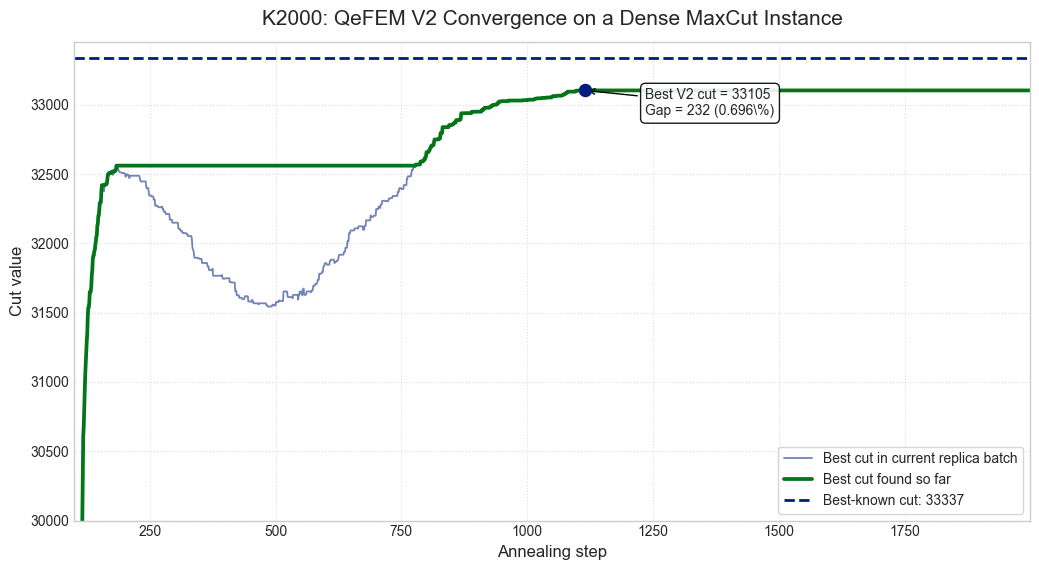

Best cut: 33105
Best step: 1115
Gap: 232
Gap percent: 0.6959%
Saved to: /Users/ronit/Desktop/QeFEM/main/maxcut_results/v2/full_res/presentation_plots/k2000_v2_convergence.pdf


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use("seaborn-v0_8-whitegrid")

# ============================================================
# Load K2000 V2 history
# ============================================================
HISTORY_PATH = Path.home() / (
    "Desktop/QeFEM/main/maxcut_results/v2/full_res/"
    "K2000_qefem_v2_anneal_history.csv"
)

OUT_DIR = HISTORY_PATH.parent / "presentation_plots"
OUT_DIR.mkdir(parents=True, exist_ok=True)

k2000 = pd.read_csv(HISTORY_PATH)

step = k2000["global_step"]
batch_best = k2000["hard_cut_max"]
best_so_far = k2000["best_cut_so_far"]

best_known = float(k2000["best_known_cut"].iloc[-1])
final_best = float(best_so_far.max())
best_step = int(k2000.loc[best_so_far.idxmax(), "global_step"])
final_gap = best_known - final_best
final_gap_percent = 100.0 * final_gap / best_known


# ============================================================
# Convergence plot
# ============================================================
fig, ax = plt.subplots(figsize=(10.5, 5.8))

ax.plot(
    step,
    batch_best,
    linewidth=1.3,
    alpha=0.55,
    label="Best cut in current replica batch"
)

ax.plot(
    step,
    best_so_far,
    linewidth=2.7,
    label="Best cut found so far"
)

ax.axhline(
    best_known,
    linestyle="--",
    linewidth=2.0,
    label=rf"Best-known cut: {best_known:.0f}"
)

ax.scatter(
    best_step,
    final_best,
    s=75,
    zorder=5
)

ax.annotate(
    rf"Best V2 cut = {final_best:.0f}" "\n"
    rf"Gap = {final_gap:.0f} ({final_gap_percent:.3f}\%)",
    xy=(best_step, final_best),
    xytext=(best_step + 120, final_best - 180),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.35", facecolor="white", alpha=0.9)
)

# Focus on the meaningful convergence region
ax.set_xlim(100, step.max())
ax.set_ylim(30000, best_known + 120)

ax.set_title(
    "K2000: QeFEM V2 Convergence on a Dense MaxCut Instance",
    fontsize=15,
    pad=12
)
ax.set_xlabel("Annealing step", fontsize=12)
ax.set_ylabel("Cut value", fontsize=12)

ax.grid(True, linestyle=":", alpha=0.65)
ax.legend(frameon=True, fontsize=10, loc="lower right")

fig.tight_layout()

pdf_path = OUT_DIR / "k2000_v2_convergence.pdf"
png_path = OUT_DIR / "k2000_v2_convergence.png"

fig.savefig(pdf_path, bbox_inches="tight")
fig.savefig(png_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Best cut: {final_best:.0f}")
print(f"Best step: {best_step}")
print(f"Gap: {final_gap:.0f}")
print(f"Gap percent: {final_gap_percent:.4f}%")
print(f"Saved to: {pdf_path}")